# Notebook 04 — Escalamiento y Reducción de Dimensionalidad (PCA)

**Dataset:** streaming_users_clean.csv  
**Objetivo:** Aplicar escalamiento y Análisis de Componentes Principales (PCA) sobre las variables numéricas del dataset, documentar las decisiones tomadas e interpretar los resultados en el contexto del proyecto.

**¿Qué es PCA?**  
El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad. Toma un conjunto de variables originales (posiblemente correlacionadas) y las transforma en nuevas variables llamadas **componentes principales**, que son combinaciones lineales de las originales. Estas componentes son ortogonales entre sí (no correlacionadas) y se ordenan de mayor a menor varianza explicada.

**¿Para qué sirve aquí?**  
Con solo 3 variables numéricas (age, monthly_watch_time_mins, customer_support_tickets), el PCA nos permite entender qué combinación de variables explica mejor la variabilidad entre usuarios y si existe alguna estructura latente en los datos.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset procesado utilizando la ruta relativa estricta
df = pd.read_csv('../data/processed/streaming_users_clean.csv')
print(f'Dataset cargado: {df.shape}')
display(df.head(3))

Dataset cargado: (5874, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,16599,49,Básico,0.0,Colombia,Romance,2018-01-01,0
1,17526,48,Básico,266.3,Perú,Comedia,2018-01-01,0
2,16245,45,Básico,521.5,Uruguay,Acción,2018-01-01,1


## Sección 1 — Selección de variables para PCA

**Evidencia y justificación:**  
El PCA requiere variables numéricas continuas o discretas. Del dataset procesado, las variables que cumplen esta condición son:
- `age`: edad del usuario (numérica continua)
- `monthly_watch_time_mins`: tiempo de visualización mensual en minutos (numérica continua)
- `customer_support_tickets`: cantidad de tickets generados (numérica discreta)

Las variables `subscription_plan`, `country`, `favorite_genre` son categóricas y se excluyen del PCA. La variable `last_login_date` es temporal y tampoco se incluye en este análisis.

**Decisión:** Se utilizarán las 3 variables numéricas disponibles para el PCA.

In [4]:
# Selección de variables numéricas para PCA
variables_pca = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[variables_pca].copy()

print('Variables seleccionadas para PCA:')
print(X.describe().round(2))
print(f'\nNulos en variables seleccionadas: {X.isnull().sum().sum()}')

Variables seleccionadas para PCA:
           age  monthly_watch_time_mins  customer_support_tickets
count  5874.00                  5874.00                   5874.00
mean     35.64                   877.21                      0.74
std      10.24                  1985.34                      0.86
min      18.00                     0.00                      0.00
25%      28.00                   500.40                      0.00
50%      35.00                   772.20                      1.00
75%      42.00                  1061.30                      1.00
max      80.00                 50000.00                      5.00

Nulos en variables seleccionadas: 0


## Sección 2 — Escalamiento con StandardScaler

**¿Por qué escalar antes del PCA?**  
El PCA es sensible a la magnitud de las variables. Sin escalamiento, `monthly_watch_time_mins` (que tiene valores de cientos a miles de minutos) dominaría completamente las componentes principales, ignorando el aporte de `age` (valores de 18 a 100) y `customer_support_tickets` (valores de 0 a ~10).

**Decisión:** Se aplica `StandardScaler` que transforma cada variable para que tenga **media = 0 y desviación estándar = 1**. Esto garantiza que cada variable contribuya equitativamente al PCA independientemente de su escala original.

**¿Qué hace StandardScaler?**  
Para cada valor x: `x_escalado = (x - media) / desviacion_estandar`

Estadísticas ANTES del escalamiento:
           age  monthly_watch_time_mins  customer_support_tickets
count  5874.00                  5874.00                   5874.00
mean     35.64                   877.21                      0.74
std      10.24                  1985.34                      0.86
min      18.00                     0.00                      0.00
25%      28.00                   500.40                      0.00
50%      35.00                   772.20                      1.00
75%      42.00                  1061.30                      1.00
max      80.00                 50000.00                      5.00

Estadísticas DESPUÉS del escalamiento (media≈0, std≈1):
             age  monthly_watch_time_mins  customer_support_tickets
count  5874.0000                5874.0000                 5874.0000
mean      0.0000                   0.0000                   -0.0000
std       1.0001                   1.0001                    1.0001
min      -1.7226                  -0.441

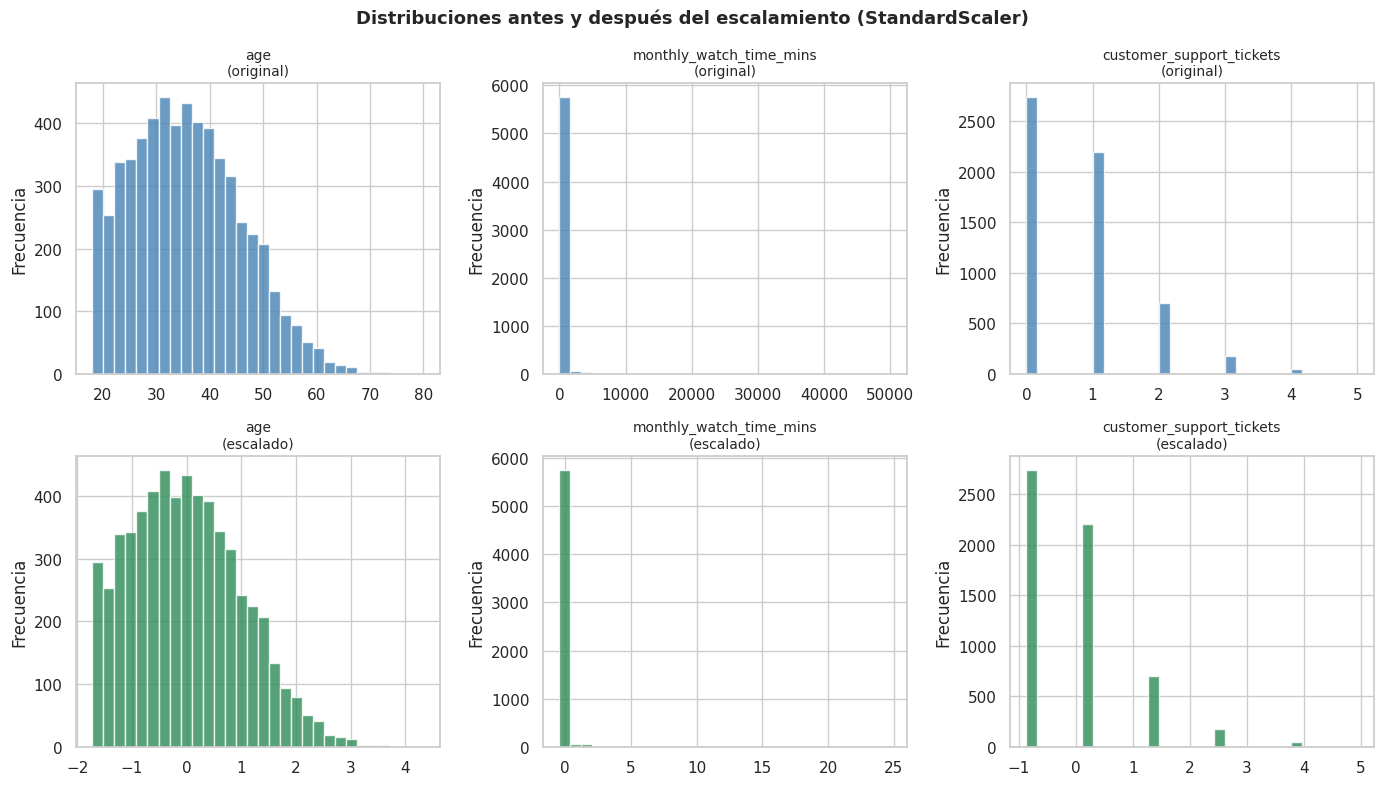

In [5]:
# Aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=variables_pca)

print('Estadísticas ANTES del escalamiento:')
print(X.describe().round(2))
print('\nEstadísticas DESPUÉS del escalamiento (media≈0, std≈1):')
print(X_scaled_df.describe().round(4))

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, var in enumerate(variables_pca):
    axes[0, i].hist(X[var], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{var}\n(original)', fontsize=10)
    axes[0, i].set_ylabel('Frecuencia')

    axes[1, i].hist(X_scaled_df[var], bins=30, color='seagreen', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{var}\n(escalado)', fontsize=10)
    axes[1, i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones antes y después del escalamiento (StandardScaler)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Sección 3 — Aplicación del PCA

**Decisión:** Se aplica PCA con `n_components=3` para obtener todas las componentes posibles (dado que tenemos 3 variables). Luego se analiza la varianza explicada por cada componente para decidir cuántas conservar.

In [6]:
# Aplicar PCA con todas las componentes posibles
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print('Varianza explicada por cada componente principal:')
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f'  PC{i+1}: {var*100:.2f}% (acumulada: {acum*100:.2f}%)')

print('\nCargas de cada variable en cada componente (loadings):')
loadings = pd.DataFrame(
    pca.components_.T,
    index=variables_pca,
    columns=[f'PC{i+1}' for i in range(3)]
)
print(loadings.round(4))

Varianza explicada por cada componente principal:
  PC1: 33.69% (acumulada: 33.69%)
  PC2: 33.46% (acumulada: 67.15%)
  PC3: 32.85% (acumulada: 100.00%)

Cargas de cada variable en cada componente (loadings):
                             PC1     PC2     PC3
age                       0.5625 -0.5972 -0.5718
monthly_watch_time_mins   0.3375  0.7972 -0.5006
customer_support_tickets  0.7548  0.0886  0.6500


## Sección 4 — Visualización de varianza explicada (Scree Plot)

**¿Qué es el Scree Plot?**  
Es un gráfico que muestra cuánta varianza explica cada componente principal. Sirve para decidir cuántas componentes conservar: generalmente se busca el punto donde agregar más componentes aporta poca varianza adicional.

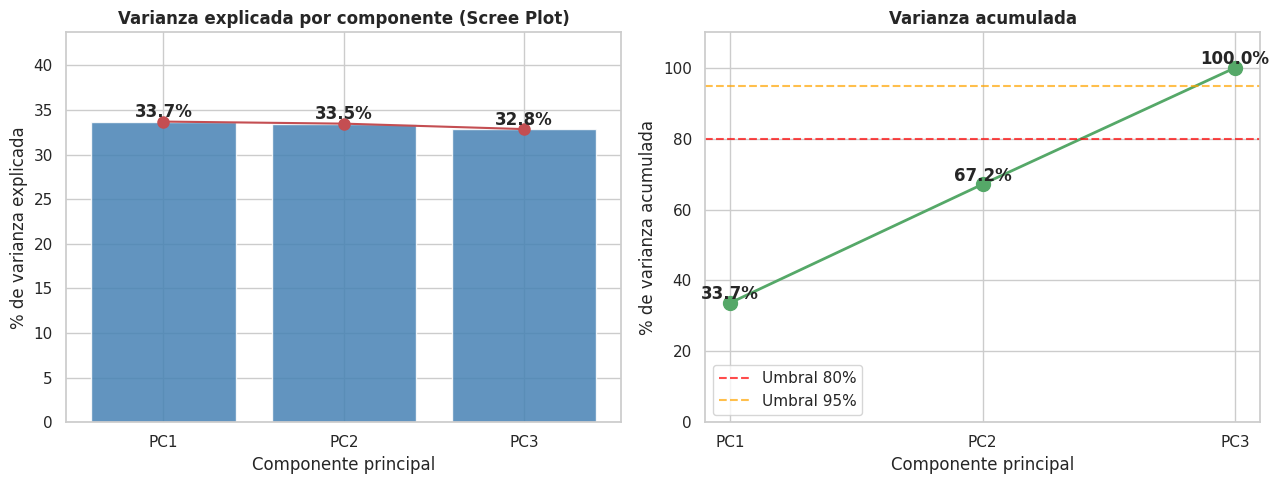

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

componentes = [f'PC{i+1}' for i in range(3)]

# Scree plot
axes[0].bar(componentes, varianza_explicada * 100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].plot(componentes, varianza_explicada * 100, 'ro-', markersize=8)
for i, v in enumerate(varianza_explicada):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Varianza explicada por componente (Scree Plot)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% de varianza explicada')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylim(0, max(varianza_explicada)*100 + 10)

# Varianza acumulada
axes[1].plot(componentes, varianza_acumulada * 100, 'go-', markersize=10, linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='Umbral 80%')
axes[1].axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='Umbral 95%')
for i, v in enumerate(varianza_acumulada):
    axes[1].text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Varianza acumulada', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% de varianza acumulada')
axes[1].set_xlabel('Componente principal')
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.tight_layout()
plt.show()

## Sección 5 — Visualización de las cargas (Biplot / Loadings)

**¿Qué son los loadings?**  
Los loadings indican cuánto contribuye cada variable original a cada componente principal. Un loading alto (positivo o negativo) significa que esa variable tiene mucho peso en esa componente.

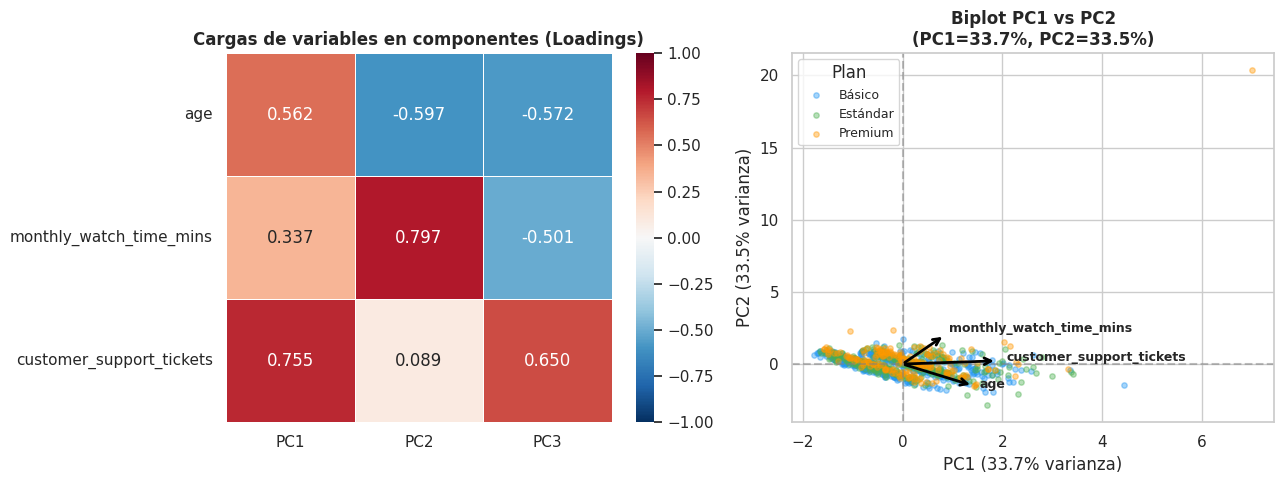

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap de loadings
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Cargas de variables en componentes (Loadings)', fontsize=12, fontweight='bold')

# Biplot PC1 vs PC2 (muestra de puntos coloreados por plan)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['subscription_plan'] = df['subscription_plan'].values

colores_plan = {'Básico': '#2196F3', 'Estándar': '#4CAF50', 'Premium': '#FF9800'}
muestra_idx = df_pca.sample(min(1000, len(df_pca)), random_state=42).index

for plan, color in colores_plan.items():
    mask = df_pca.loc[muestra_idx, 'subscription_plan'] == plan
    axes[1].scatter(
        df_pca.loc[muestra_idx][mask]['PC1'],
        df_pca.loc[muestra_idx][mask]['PC2'],
        c=color, label=plan, alpha=0.4, s=15
    )

# Vectores de carga
scale = 2.5
for i, var in enumerate(variables_pca):
    axes[1].annotate('', xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                     xytext=(0,0), arrowprops=dict(arrowstyle='->', color='black', lw=2))
    axes[1].text(pca.components_[0,i]*scale*1.1, pca.components_[1,i]*scale*1.1,
                 var, fontsize=9, fontweight='bold')

axes[1].set_title(f'Biplot PC1 vs PC2\n(PC1={varianza_explicada[0]*100:.1f}%, PC2={varianza_explicada[1]*100:.1f}%)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}% varianza)')
axes[1].legend(title='Plan', fontsize=9)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Sección 6 — Interpretación de los resultados del PCA

**Varianza explicada:**  
Con 3 variables numéricas, el PCA produce 3 componentes que en conjunto explican el 100% de la varianza. El punto crítico es cuánta varianza explican las primeras componentes:

- Si **PC1 + PC2 explican ≥ 80%** de la varianza, podemos representar el dataset en 2 dimensiones con poca pérdida de información.
- Si la varianza está muy distribuida entre las 3 componentes (ej. ~33% cada una), indica que las variables son **independientes entre sí**, lo que es consistente con la matriz de correlación observada en el EDA.

**Interpretación de los loadings:**
- La variable con mayor loading absoluto en PC1 es la que más contribuye a esa componente.
- Variables con loadings similares en una componente comparten variabilidad.
- Variables con loadings opuestos en una componente tienen relación inversa.

**Conclusión del PCA:**  
La baja correlación entre las variables numéricas observada en el EDA se refleja en el PCA: la varianza está distribuida entre las componentes. Esto implica que cada variable aporta información relativamente independiente sobre el comportamiento del usuario. Para una reducción de dimensionalidad eficiente en este dataset, se recomendaría incorporar variables adicionales en análisis futuros.

In [9]:
print('=== RESUMEN FINAL DEL PCA ===')
print(f'\nVariables utilizadas: {variables_pca}')
print(f'Escalamiento aplicado: StandardScaler (media=0, std=1)')
print(f'\nVarianza explicada:')
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f'  PC{i+1}: {var*100:.2f}% individual | {acum*100:.2f}% acumulada')
print(f'\nLoadings (contribución de cada variable a cada componente):')
print(loadings.round(4))
print(f'\nObservación: La distribución de varianza entre componentes es consistente')
print(f'con la baja correlación entre variables observada en el EDA.')

=== RESUMEN FINAL DEL PCA ===

Variables utilizadas: ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
Escalamiento aplicado: StandardScaler (media=0, std=1)

Varianza explicada:
  PC1: 33.69% individual | 33.69% acumulada
  PC2: 33.46% individual | 67.15% acumulada
  PC3: 32.85% individual | 100.00% acumulada

Loadings (contribución de cada variable a cada componente):
                             PC1     PC2     PC3
age                       0.5625 -0.5972 -0.5718
monthly_watch_time_mins   0.3375  0.7972 -0.5006
customer_support_tickets  0.7548  0.0886  0.6500

Observación: La distribución de varianza entre componentes es consistente
con la baja correlación entre variables observada en el EDA.
